# SiT-XL/2 Inference



## 1. Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
RESULTS_DIR = '/content/drive/MyDrive/repa-results'
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Drive mounted. Results will be saved to:', RESULTS_DIR)

Mounted at /content/drive
Drive mounted. Results will be saved to: /content/drive/MyDrive/repa-results


## 2. Install dependencies

In [2]:
%%bash
pip install -q accelerate diffusers timm einops

## 3. Clone REPA fork

In [3]:
%%bash
if [ ! -d "/content/REPA" ]; then
    git clone https://github.com/nikiboura/REPA.git /content/REPA
fi
cd /content/REPA && git pull
echo "REPA ready. Commit: $(git rev-parse --short HEAD)"

Already up to date.
REPA ready. Commit: 5a9b0a0


Cloning into '/content/REPA'...


## 4. Generate images with SiT-XL/2

- Φορτώνει το **SiT-XL/2**
- Για κάθε εικόνα: αρχίζει από **pure Gaussian noise** στο latent space και το κάνει denoise σε 250 βήματα με SDE sampler.
- Το **VAE** (`ema`) αποκωδικοποιεί το latent πίσω σε pixel space
- **CFG (Classifier-Free Guidance)**: scale=1.8, guidance-high=0.7 — το μοντέλο κάνει δύο forward passes (conditional + unconditional) και τα συνδυάζει για καλύτερη ποιότητα.
- Αποθηκεύει όλες τις εικόνες σε ένα `.npz` αρχείο.

In [14]:
  import subprocess, os

  cmd = [
      'torchrun', '--nnodes=1', '--nproc_per_node=1', '--master_port=29501',
      '/content/REPA/generate.py',
      '--model',                'SiT-XL/2',
      '--num-fid-samples',      '5000',
      '--path-type',            'linear',
      '--encoder-depth',        '8',
      '--projector-embed-dims', '768',
      '--per-proc-batch-size',  '32',
      '--mode',                 'sde',
      '--num-steps',            '250',
      '--cfg-scale',            '1.8',
      '--guidance-high',        '0.7',  #στο πρώτο 70% των steps
  ]

  process = subprocess.Popen(
      cmd, cwd='/content/REPA',
      stdout=subprocess.PIPE,
      stderr=subprocess.STDOUT,
      text=True
  )
  for line in process.stdout:
      print(line, end='', flush=True)
  process.wait()
  print('Exit code:', process.returncode)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Starting rank=0, seed=0, world_size=1.

  0%|          | 0.00/2.73G [00:00<?, ?B/s]
  0%|          | 4.23M/2.73G [00:00<02:09, 21.1MB/s]
  0%|          | 8.42M/2.73G [00:00<02:07, 21.3MB/s]
  0%|          | 12.6M/2.73G [00:00<02:07, 21.4MB/s]
  1%|          | 16.8M/2.73G [00:00<02:05, 21.6MB/s]
  1%|          | 21.0M/2.73G [00:00<02:05, 21.7MB/s]
  1%|          | 25.2M/2.73G [00:01<02:04, 21.8MB/s]
  1%|          | 29.4M/2.73G [00:01<02:03, 21.8MB/s]
  1%|          | 33.6M/2.73G [00:01<02:03, 21.8MB/s]
  1%|▏         | 37.8M/2.73G [00:01<02:03, 21.9MB/s]
  2%|▏         | 42.0M/2.73G [00:01<02:03, 21.8MB/s]
  2%|▏         | 46.2M/2.73G [00:02<02:03, 21.8MB/s]
  2%|▏         | 50.4M/2.73G [00:02

## 5. Save .npz to Drive

Αντιγράφει το `.npz` με τις generated εικόνες στο Google Drive.

In [15]:
import glob, shutil, os

npz_files = sorted(glob.glob('/content/REPA/samples/**/*.npz', recursive=True))
print('Found:', npz_files)

dest = os.path.join(RESULTS_DIR, 'sit_xl_5k_samples.npz')
shutil.copy(npz_files[-1], dest)
print('Saved to Drive:', dest)

Found: ['/content/REPA/samples/SiT-XL-2-SiT-XL-2-256x256-size-256-vae-ema-cfg-1.8-seed-0-sde.npz']
Saved to Drive: /content/drive/MyDrive/repa-results/sit_xl_5k_samples.npz


## 6. Show generated images

Φορτώνει το `.npz` και εμφανίζει ένα 4×4 grid από τις πρώτες 16 εικόνες.

Total generated: 5000


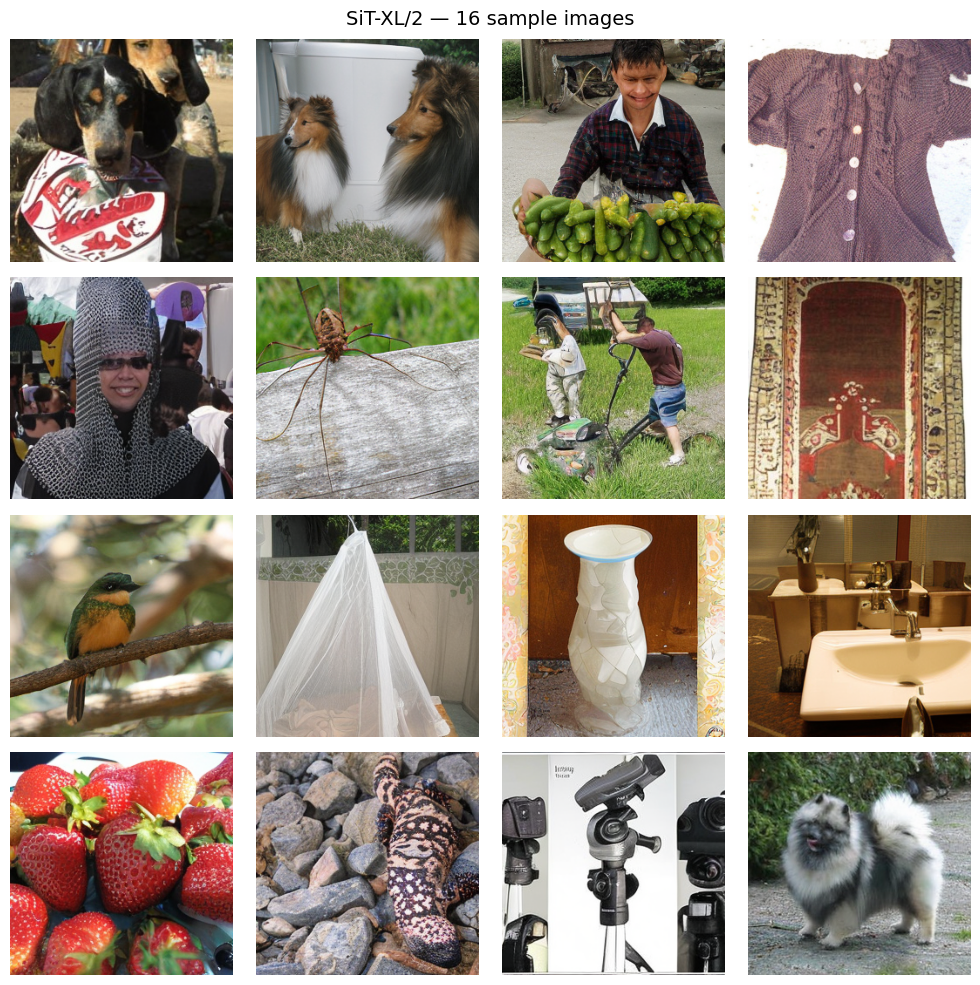

Grid saved to Drive.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import glob

npz_files = sorted(glob.glob('/content/REPA/samples/**/*.npz', recursive=True))
data = np.load(npz_files[-1])
imgs = data[data.files[0]]
print(f'Total generated: {len(imgs)}')

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].astype('uint8'))
    ax.axis('off')
plt.suptitle('SiT-XL/2 — 16 sample images', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sit_xl_samples_grid.png'), dpi=150)
plt.show()
print(f'Grid saved to Drive.')

## 7. Compute FID

Υπολογίζει το **FID score** συγκρίνοντας τις generated εικόνες με real ImageNet-256 εικόνες.



In [20]:
import os, shutil, subprocess

# Kaggle credentials
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Download ImageNet-256 val split
if not os.path.isdir('/content/imagenet256_raw'):
    subprocess.run([
        'kaggle', 'datasets', 'download',
        '-d', 'dimensi0n/imagenet-256',
        '-p', '/content/imagenet256_raw',
        '--unzip'
    ], check=True)

print('ImageNet-256 ready.')

ImageNet-256 ready.


In [22]:
import numpy as np, glob, os, subprocess
from PIL import Image
from tqdm import tqdm

subprocess.run(['pip', 'install', '-q', 'torch-fidelity'], check=True)

# Save generated images as PNGs
gen_npz = sorted(glob.glob('/content/REPA/samples/**/*.npz', recursive=True))[-1]
gen_dir = '/content/gen_images'
os.makedirs(gen_dir, exist_ok=True)
data = np.load(gen_npz)
imgs = data[data.files[0]]
for i, img in enumerate(tqdm(imgs, desc='Saving generated images')):
    Image.fromarray(img.astype('uint8')).save(f'{gen_dir}/{i:05d}.png')

real_dir = '/content/imagenet256_raw'

result = subprocess.run([
      'fidelity', '--gpu', '0', '--fid',
      '--samples-find-deep',
      '--input1', gen_dir,
      '--input2', real_dir,
], capture_output=True, text=True)

print(result.stdout)
print(result.stderr)

Saving generated images: 100%|██████████| 5000/5000 [02:07<00:00, 39.19it/s]


frechet_inception_distance: 13.07538

Creating feature extractor "inception-v3-compat" with features ['2048']
Extracting statistics from input 1
Looking for samples recursively in "/content/gen_images" with extensions png,jpg,jpeg
Found 5000 samples

Processing samples: 100%|█████████▉| 4992/5000 [00:08<00:00, 623.99samples/s]
                                                                             
Processing samples
Extracting statistics from input 2
Looking for samples recursively in "/content/imagenet256_raw" with extensions png,jpg,jpeg
Found 539826 samples, some are lossy-compressed - this may affect metrics

Processing samples: 100%|█████████▉| 539776/539826 [14:57<00:00, 599.68samples/s]
                                                                                 
Processing samples
Frechet Inception Distance: 13.07538



### Store npz images

In [5]:
import numpy as np
from PIL import Image
import os

data = np.load("/content/drive/MyDrive/repa-results/sit_xl_5k_samples.npz")

print("Arrays:", data.files)

images = data[data.files[0]]

print("Dataset shape:", images.shape)

output_folder = "/content/drive/MyDrive/extracted_images"
os.makedirs(output_folder, exist_ok=True)

for i, img in enumerate(images):

    if len(img.shape) == 3 and img.shape[0] == 3:
        img = img.transpose(1, 2, 0)

    if img.max() <= 1:
        img = (img * 255).astype(np.uint8)

    img = img.astype(np.uint8)

    Image.fromarray(img).save(f"{output_folder}/image_{i}.png")

print(f"Saved {len(images)} images in '{output_folder}' folder.")

Arrays: ['arr_0']
Dataset shape: (5000, 256, 256, 3)
Saved 5000 images in '/content/drive/MyDrive/extracted_images' folder.
